# IEA-22 — 3-D tapered segment (shell + structured-hex solid)

This tutorial builds the **3-D tapered segment of the IEA-22-280 blade between the
`r = 0.2` and `r = 0.3` span stations**, straight from the windIO definition bundled in
this repo (`examples/data/IEA-22-280-RWT.yaml`), producing **both** SG meshes:

* the **strictly structured 8-node HEX solid** — formed from the *layup information* of the
  two boundary cross-sections (through-thickness layers use each segment's local laminate
  thickness; every hex carries the fiber frame of the ply at its depth), and
* the **equivalent mid-surface QUAD shell segment** — the same hoop skeleton and span
  stations, so shell-vs-solid comparisons are one-to-one.

Every export passes the **mandatory conformity gate**. The only external requirement is the
windIO v2 reader:

```bash
pip install windIO
```

This notebook runs `examples/iea22_hex_segment.py` (generation) and
`examples/render_iea22_segment.py` (read-back renders) inline.

## How the general two-station hex loft works

The input each time is the *boundary cross-section definition at the two ends* (here
`build_cross_section(blade, r)` at `r = 0.2` and `0.3`; a PreVABS XML station resolves to the
same information). `opensg_io.hex_loft` then:

1. **Canonical hoop skeleton** — the union of layup-segment breakpoints and **web junction
   bands** (each web occupies a band of its own thickness on the skin, subdivided `nw` times =
   the junction refinement), *label-matched between the two stations* so both get the
   **identical topology**. Meshed independently the stations would differ (chord-driven node
   counts); the shared skeleton is what makes a structured loft possible for *any* pair of
   compatible sections.
2. **Per-station realization** — skin nodes on the OML offset inward through `nr` layers using
   the **local laminate thickness**; webs are plates whose across-thickness columns attach to
   the `nw+1` **inner-skin band nodes** (top/bottom rows *are* skin nodes → a watertight,
   conforming T-junction), with depth rows **cosine-clustered** so the mesh is refined at both
   web junctions.
3. **Linear loft** — one 8-node hex per quad per span slice, marching `r = 0.2 → 0.3`. A
   conforming quad section lofts to a conforming hex mesh by construction.

Two robustness devices adopted from the PreVABS / NuMAD mesh generators:

* **Miter-offset rings** (`opensg_io.section_offset`, after PreVABS `src/geo/offset*.cpp`):
  contour orientation from the signed area, per-vertex angle-bisector normals with the
  Clipper2 miter limit, and a smoothed **thin-gap clamp** (inward ray-cast to the opposite
  wall) so the through-thickness rings never fold or cross at the thin trailing edge.
* **Positive-Jacobian guarantee** (after NuMAD `NuMesh3D.m` det check): every 2-D face is
  canonically CCW-wound before extrusion, and the export asserts the **min scaled corner
  Jacobian** of all hexes is positive.

In [1]:
import os, sys, runpy
def _root(d):
    d = os.path.abspath(d)
    while d != os.path.dirname(d):
        if os.path.isdir(os.path.join(d, "opensg_io")) and os.path.isdir(os.path.join(d, "examples")):
            return d
        d = os.path.dirname(d)
    return os.getcwd()
ROOT = _root(os.getcwd())
EX = os.path.join(ROOT, "examples")
sys.path.insert(0, ROOT)
from IPython.display import Image, display
print("repo root:", ROOT)

repo root: Y:\OpenSG_io


## Build the segment

In [2]:
# run the generation script inline (default input = the bundled windIO)
sys.argv = ["iea22_hex_segment.py"]
runpy.run_path(os.path.join(EX, "iea22_hex_segment.py"), run_name="__main__")

loading blade: Y:\OpenSG_io\examples\data\IEA-22-280-RWT.yaml


stations: r=0.20 chord=7.200 (3 webs) | r=0.30 chord=6.703  ->  z=[27.40, 41.10] m


HEX: 10101 nodes, 7296 hexes  (section: 126 hoop nodes x 4 layers + webs NY=[12, 20, 20])


conformity gate (solid): PASS   min scaled Jacobian = 0.450 (0 inverted)


wrote Y:\OpenSG_io\examples\iea22_seg_r020_r030_solid.yaml


conformity (shell, branched): PASS  (2275 nodes, 2136 quads; 72 T-junction edges as expected)


wrote Y:\OpenSG_io\examples\iea22_seg_r020_r030_shell.yaml


wrote Y:\OpenSG_io\examples\iea22_hex_segment.png


wrote Y:\OpenSG_io\examples\iea22_hex_3d.png


{'__name__': '__main__',
 '__doc__': 'iea22_hex_segment.py -- GENERAL two-station hex loft applied to the IEA-22-280 blade.\n\nBuilds the 3-D tapered segment between r=0.2 and r=0.3 from the windIO definition:\n  * conforming structured 8-node HEX solid (skin through-thickness layers + 3 webs with\n    refined, node-shared junction bands)  -> iea22_seg_r020_r030_solid.yaml\n  * the EQUIVALENT mid-surface QUAD shell segment (same hoop skeleton, same stations)\n    -> iea22_seg_r020_r030_shell.yaml\nplus cross-section / 3-D PNG renders.  The conformity gate is mandatory on both.\n\n    python examples/iea22_hex_segment.py [windio_yaml]\n',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'Y:\\OpenSG_io\\examples\\iea22_hex_segment.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, buil

## The loft input and the structured hex

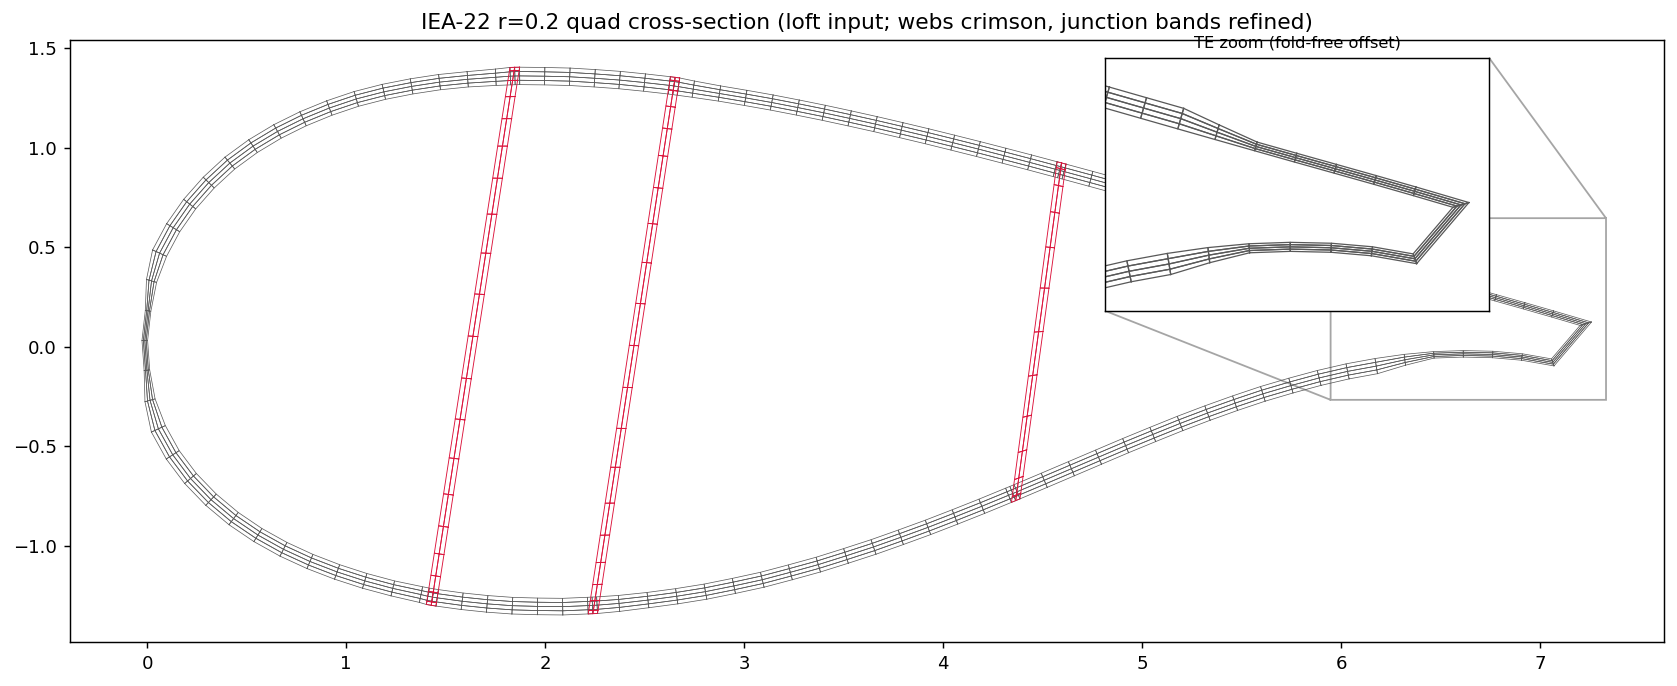

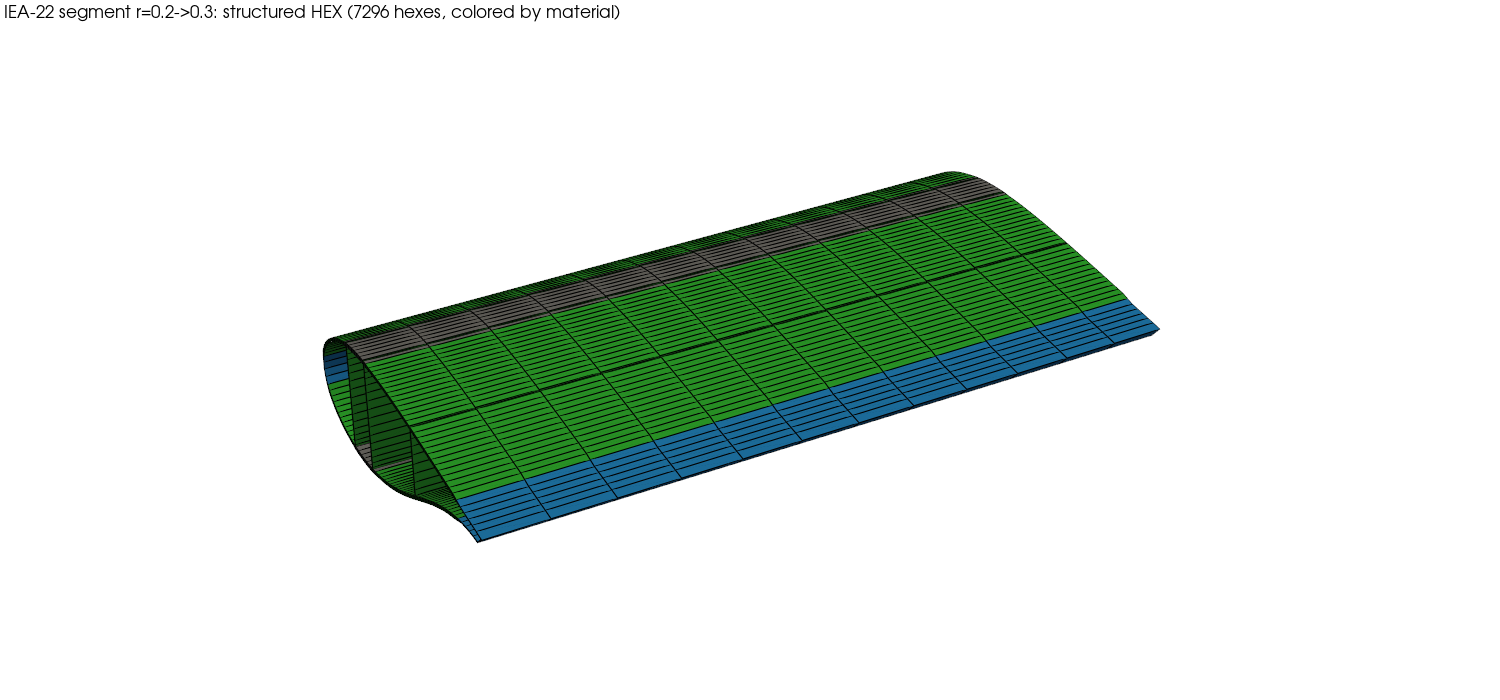

In [3]:
# the loft input (r=0.2 section with trailing-edge zoom: fold-free miter offset)
display(Image(filename=os.path.join(EX, "iea22_hex_segment.png")))
# the lofted structured hex, shaded faces + element edges (colored by material)
display(Image(filename=os.path.join(EX, "iea22_hex_3d.png")))

## The two exported segment meshes (read back from the YAMLs)

wrote Y:\OpenSG_io\examples\iea22_seg_shell.png


wrote Y:\OpenSG_io\examples\iea22_seg_solid.png


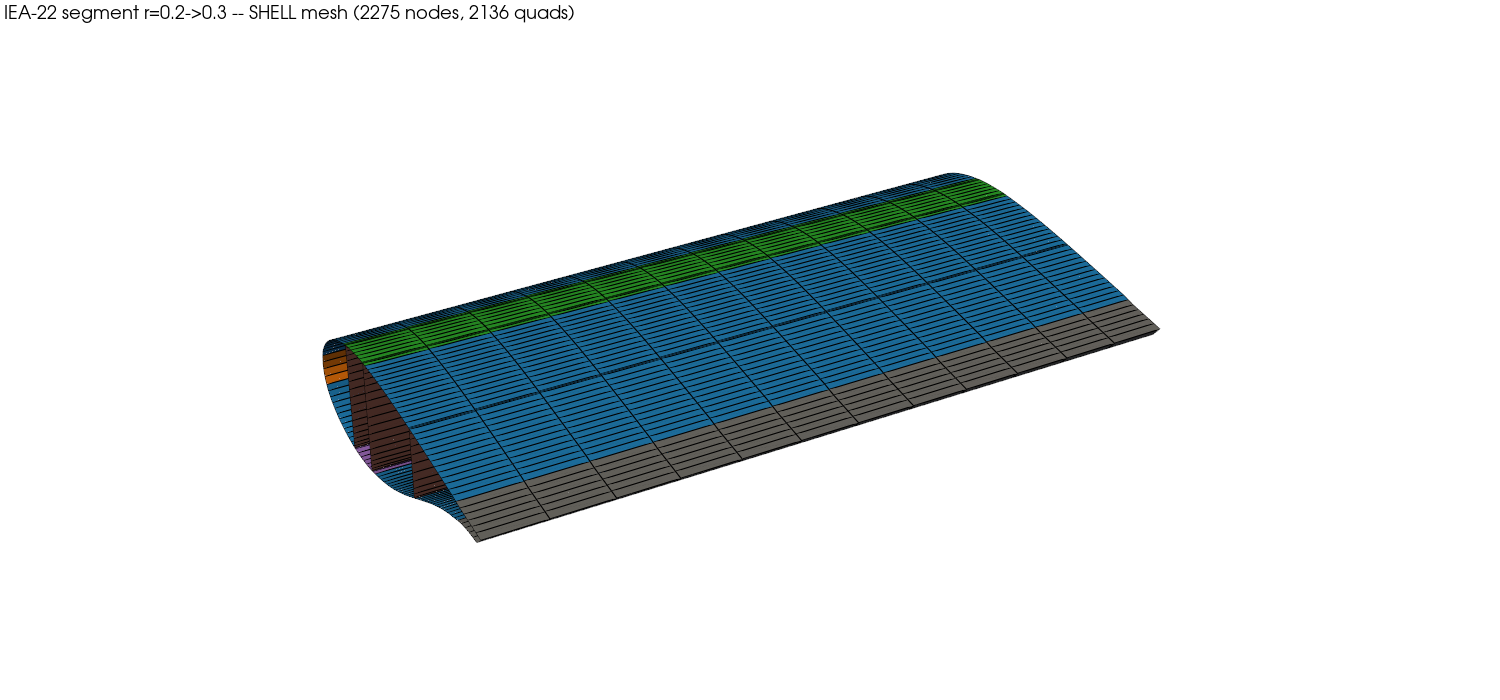

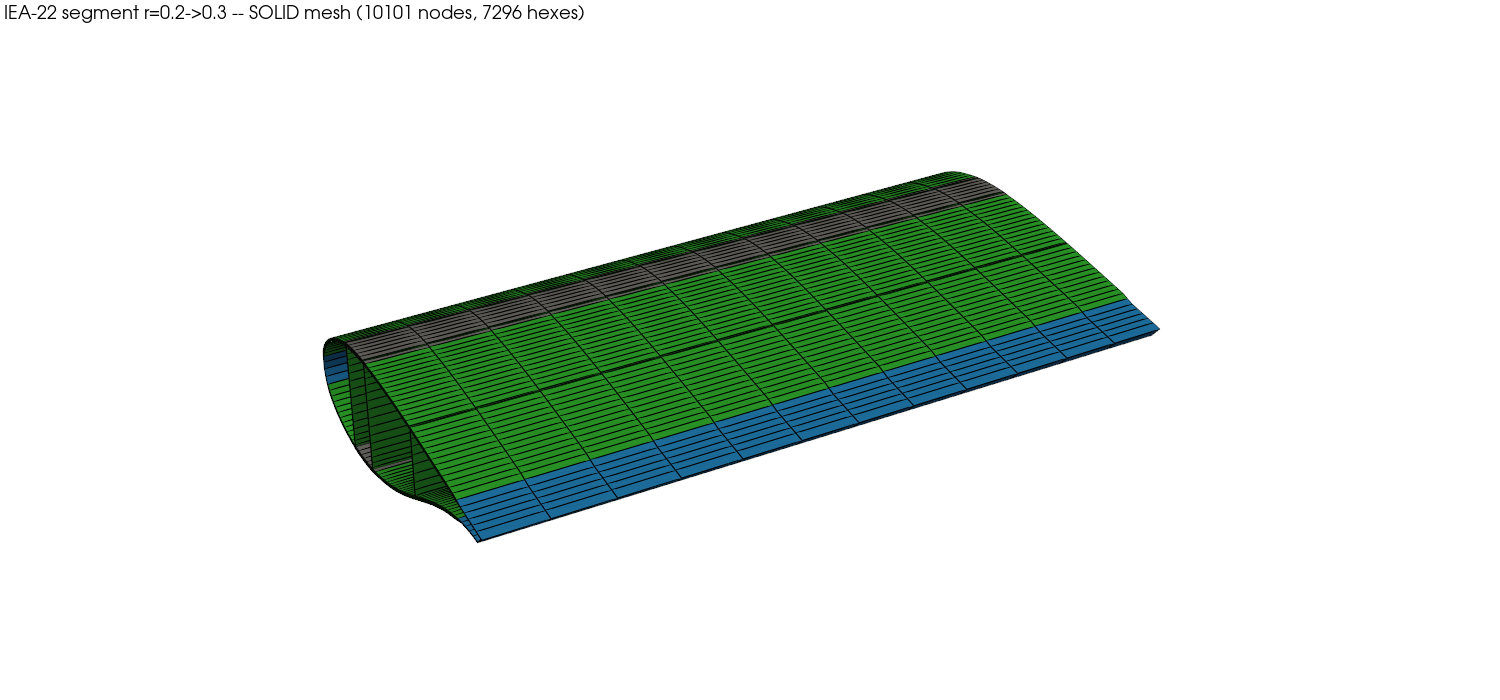

In [4]:
# read the two exported YAMLs back and render each mesh (colored by element set)
sys.argv = ["render_iea22_segment.py"]
runpy.run_path(os.path.join(EX, "render_iea22_segment.py"), run_name="__main__")
display(Image(filename=os.path.join(EX, "iea22_seg_shell.png")))
display(Image(filename=os.path.join(EX, "iea22_seg_solid.png")))

## Notes

* **Strictly structured**: hoop skeleton × `nr` through-thickness layers × `nsp` span slices —
  no unstructured fill anywhere.
* The **shell conformity check differs from the solid one**: a branched mid-surface shell
  legitimately has T-junction edges shared by exactly **3** quads (skin-left + skin-right +
  web); the script asserts exactly `2 × n_webs × nsp` such edges and none shared by more.
* The two YAMLs feed the [OpenSG-TW](https://github.com/bagla0/OpenSG-TW) homogenizers
  (RM shell segment ↔ FEniCS 3-D solid) for the tapered Timoshenko 6×6.
* Refinement knobs: `mesh_size` (hoop), `nr` (through-thickness), `nsp` (span), `nw` (junction
  band). The thin trailing-edge region is where to spend `mesh_size` if the downstream solve
  needs it.